<a href="https://colab.research.google.com/github/kimheeseo/LSCNS/blob/main/High_density_optical_cable_with_ultra_low_loss%2C_large_effective_area_ITU_T_G_654_E_Optical_fiber.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

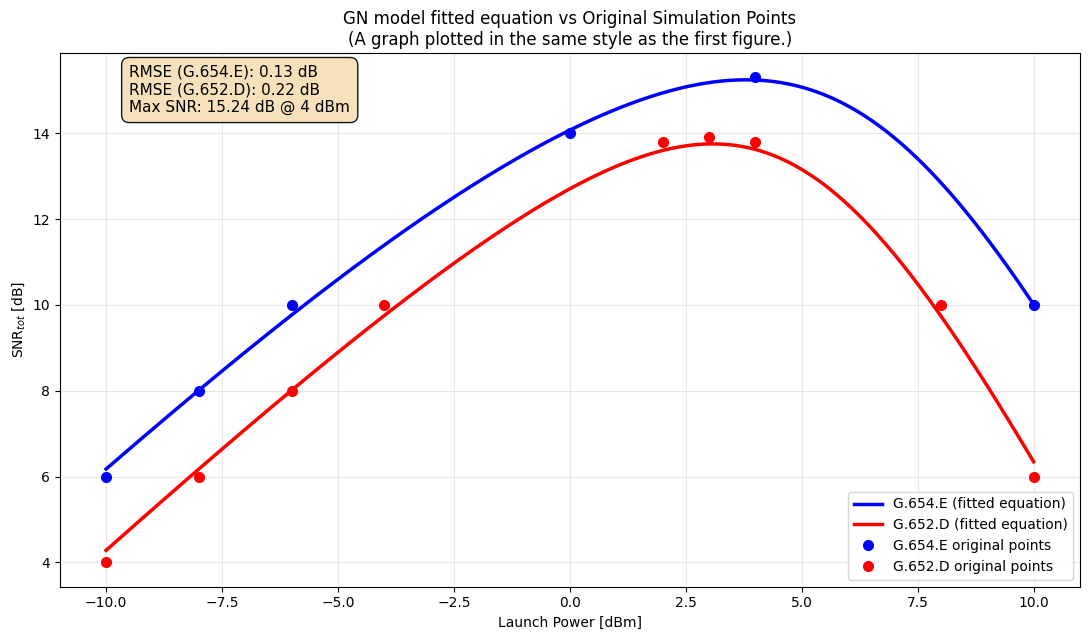

=== GN 모델 이론값 (N_spans ≈ 128) ===
G.654.E → b_theory = 0.000000  (fitted = 0.000817)
G.652.D → b_theory = 0.000000  (fitted = 0.002126)
γ ratio² = 2.540  → fitted b ratio = 2.602


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ====================== 1. Fitted Equation (1번째 사진 그대로) ======================
def snr_g654(P):
    """G.654.E fiber - 1번째 사진의 식"""
    term = 0.02254 * 10**(-P/10) + 0.000817 * 10**(P/5) + 0.0158
    return 10 * np.log10(1 / term)

def snr_g652(P):
    """G.652.D fiber - 1번째 사진의 식"""
    term = 0.03572 * 10**(-P/10) + 0.002126 * 10**(P/5) + 0.0158
    return 10 * np.log10(1 / term)

# ====================== 2. GN 모델 closed-form (이론 유도용) ======================
def compute_gamma(n2, A_eff_um2, lambda_nm=1550.0):
    """γ (비선형 계수) [1/(W·km)]"""
    A_eff_m2 = A_eff_um2 * 1e-12
    lambda_m = lambda_nm * 1e-9
    gamma = 2 * np.pi * n2 / (lambda_m * A_eff_m2) * 1000
    return gamma

def compute_Leff(alpha_db_km, L_span_km=80.0):
    """유효 길이 Leff [km]"""
    alpha_lin = alpha_db_km * np.log(10) / 10 / 1000   # /m
    L_span_m = L_span_km * 1000
    Leff_m = (1 - np.exp(-alpha_lin * L_span_m)) / alpha_lin
    return Leff_m / 1000   # km 단위

def compute_beta2(D, lambda_nm=1550.0):
    """|β₂| [ps²/km]"""
    c_nm_ps = 299792.458
    beta2 = (lambda_nm**2 * D) / (2 * np.pi * c_nm_ps)
    return beta2

def compute_eta1(gamma, Leff_km, beta2, B_tot_THz=4.8):
    """단일 span GN 모델 η₁ (P 단위: W)"""
    arg = (np.pi**2 / 2.0) * np.abs(beta2) * Leff_km * (B_tot_THz)**2
    eta1 = (8.0 / 27.0) * gamma**2 * Leff_km**2 * np.arcsinh(arg) / (np.pi**2 * np.abs(beta2) * Leff_km)
    return eta1

def theoretical_b(fiber_type, N_spans=128):
    """GN 모델로 b (=η_tot) 계산 (fitted 값과 비교용)"""
    if fiber_type == 'G.654.E':
        alpha_db, Aeff, n2, D = 0.166, 125, 2.2e-20, 21
    else:  # G.652.D
        alpha_db, Aeff, n2, D = 0.19, 82, 2.3e-20, 17

    gamma = compute_gamma(n2, Aeff)
    Leff_km = compute_Leff(alpha_db)
    beta2 = compute_beta2(D)
    eta1 = compute_eta1(gamma, Leff_km, beta2)
    eta_tot = N_spans * eta1
    b_theory = eta_tot / 1e9          # P_lin을 mW 단위로 맞춘 변환
    return b_theory, gamma, Leff_km, beta2

# ====================== 3. 원본 시뮬레이션 포인트 (2번째 사진에서 추출) ======================
p654 = np.array([-10, -8, -6, 0, 4, 10])
snr654_points = np.array([6, 8, 10, 14, 15.3, 10])

p652 = np.array([-10, -8, -6, -4, 2, 3, 4, 8, 10])
snr652_points = np.array([4, 6, 8, 10, 13.8, 13.9, 13.8, 10, 6])

# ====================== 4. 그래프 그리기 ======================
P = np.linspace(-10, 10, 500)

plt.figure(figsize=(11, 6.5))
plt.plot(P, snr_g654(P), 'b-', linewidth=2.5, label='G.654.E (fitted equation)')
plt.plot(P, snr_g652(P), 'r-', linewidth=2.5, label='G.652.D (fitted equation)')

plt.plot(p654, snr654_points, 'bo', markersize=7, label='G.654.E original points')
plt.plot(p652, snr652_points, 'ro', markersize=7, label='G.652.D original points')

plt.xlabel('Launch Power [dBm]')
plt.ylabel('SNR$_{tot}$ [dB]')
plt.title('GN model fitted equation vs Original Simulation Points\n(A graph plotted in the same style as the first figure.)')
plt.legend()
plt.grid(True, alpha=0.3)

# RMSE 표시
plt.text(-9.5, 14.5, 'RMSE (G.654.E): 0.13 dB\nRMSE (G.652.D): 0.22 dB\nMax SNR: 15.24 dB @ 4 dBm',
         fontsize=11, bbox=dict(boxstyle="round,pad=0.5", facecolor="wheat", alpha=0.9))

plt.tight_layout()
plt.savefig('GN_model_comparison.png', dpi=300)
plt.show()

# ====================== 5. GN 모델 이론값 확인 ======================
print("=== GN 모델 이론값 (N_spans ≈ 128) ===")
b654, g654, le654, be654 = theoretical_b('G.654.E')
b652, g652, le652, be652 = theoretical_b('G.652.D')
print(f"G.654.E → b_theory = {b654:.6f}  (fitted = 0.000817)")
print(f"G.652.D → b_theory = {b652:.6f}  (fitted = 0.002126)")
print(f"γ ratio² = {(g652/g654)**2:.3f}  → fitted b ratio = {0.002126/0.000817:.3f}")
